In [1]:
%pip install mne

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import mne
from mne.datasets import eegbci 
raw_fnames = eegbci.load_data(subject=1, runs=[1]) 
raw = mne.io.read_raw_edf(raw_fnames[0], preload=True) 
print(raw.info)

Extracting EDF parameters from /Users/olivialee/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: 3 items (dict)
>


In [3]:
raw.rename_channels(lambda x: x.strip('.')) 
montage = mne.channels.make_standard_montage('standard_1020') 
raw.set_montage(montage, match_case = False) 

<RawEDF | S001R01.edf, 64 x 9760 (61.0 s), ~4.9 MB, data loaded>

Using matplotlib as 2D backend.


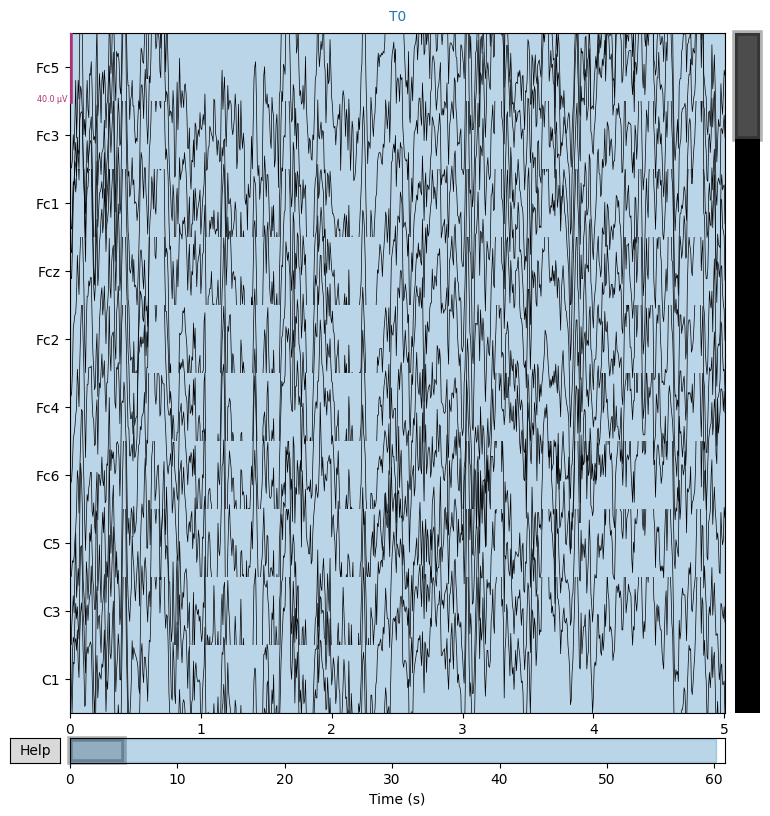

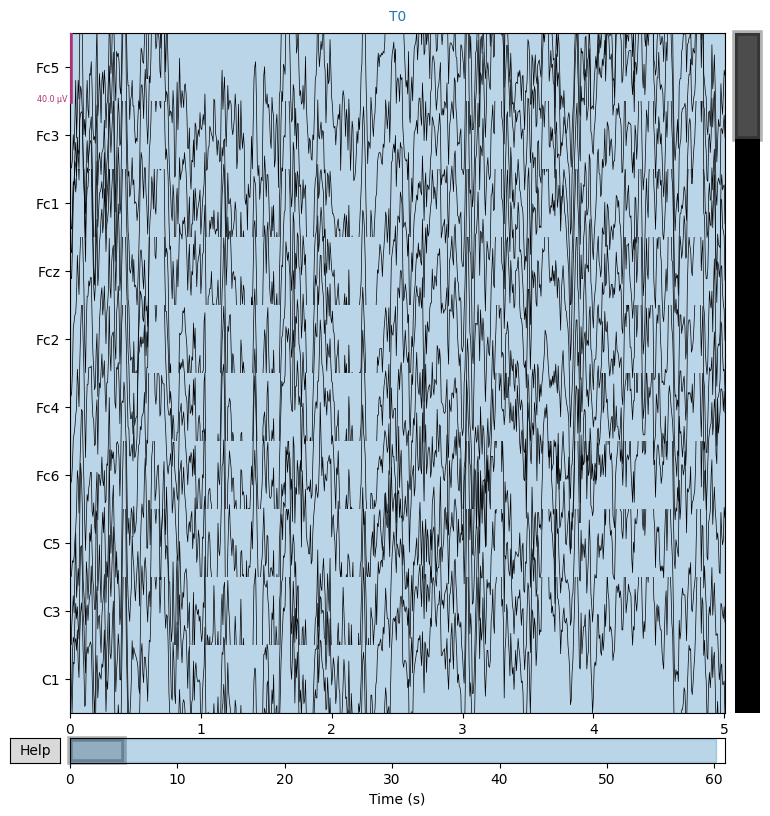

In [4]:
raw.plot(duration=5, n_channels=10) 

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 529 samples (3.306 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.0s finished


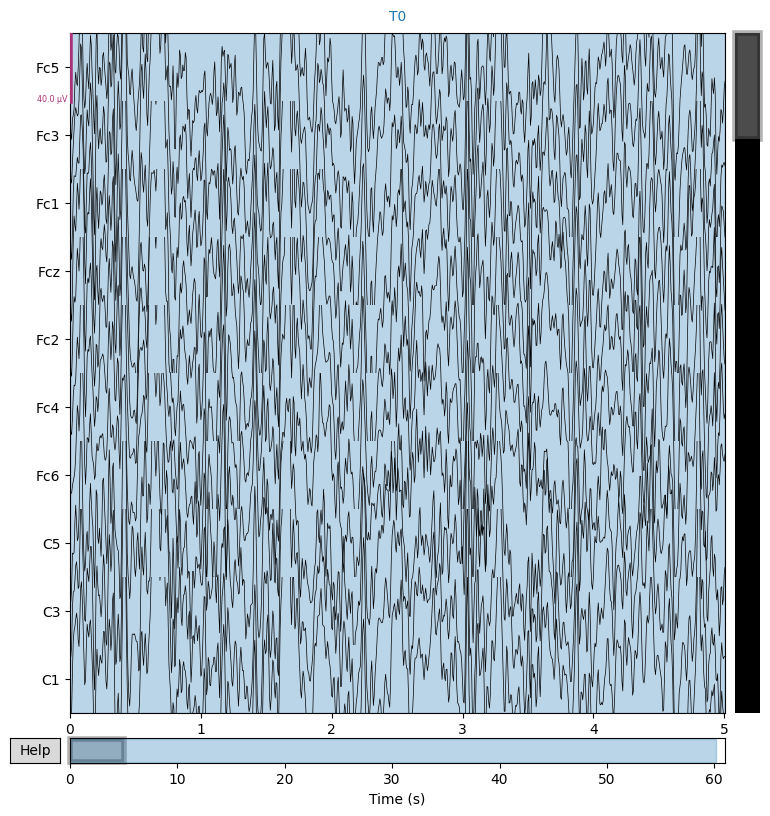

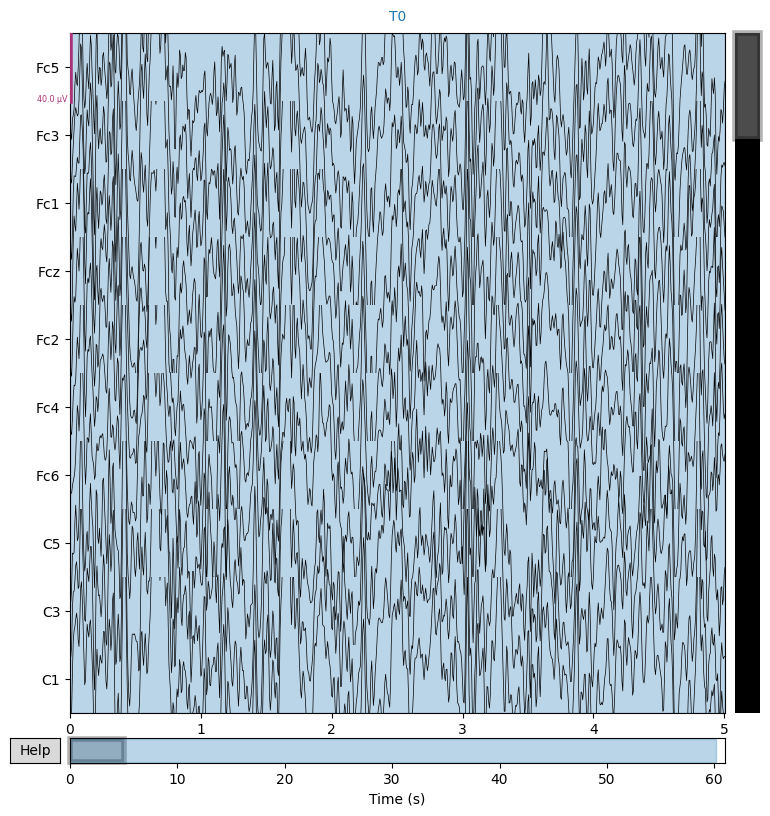

In [5]:
raw_filtered = raw.copy().filter(l_freq=1.0, h_freq=40.0, fir_design='firwin') 
raw_filtered.plot(duration=5, n_channels=10) 

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 0.3s.


/Users/olivialee/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1449: RuntimeWarning: divide by zero encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/olivialee/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1449: RuntimeWarning: overflow encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/olivialee/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1449: RuntimeWarning: invalid value encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/olivialee/Library/Python/3.9/lib/python/site-packages/mne/utils/linalg.py:243: RuntimeWarning: divide by zero encountered in matmul
  return (u @ vh[:rank]).conj().T
/Users/olivialee/Library/Python/3.9/lib/python/site-packages/mne/utils/linalg.py:243: RuntimeWarning: overflow encountered in matmul
  return (u @ vh[:rank]).conj().T
/Users/olivialee/Library/Python/3.9/lib/python/site-packages/mne/utils/linalg.py:243: RuntimeWarning: invalid value encountered in matmul
  retur

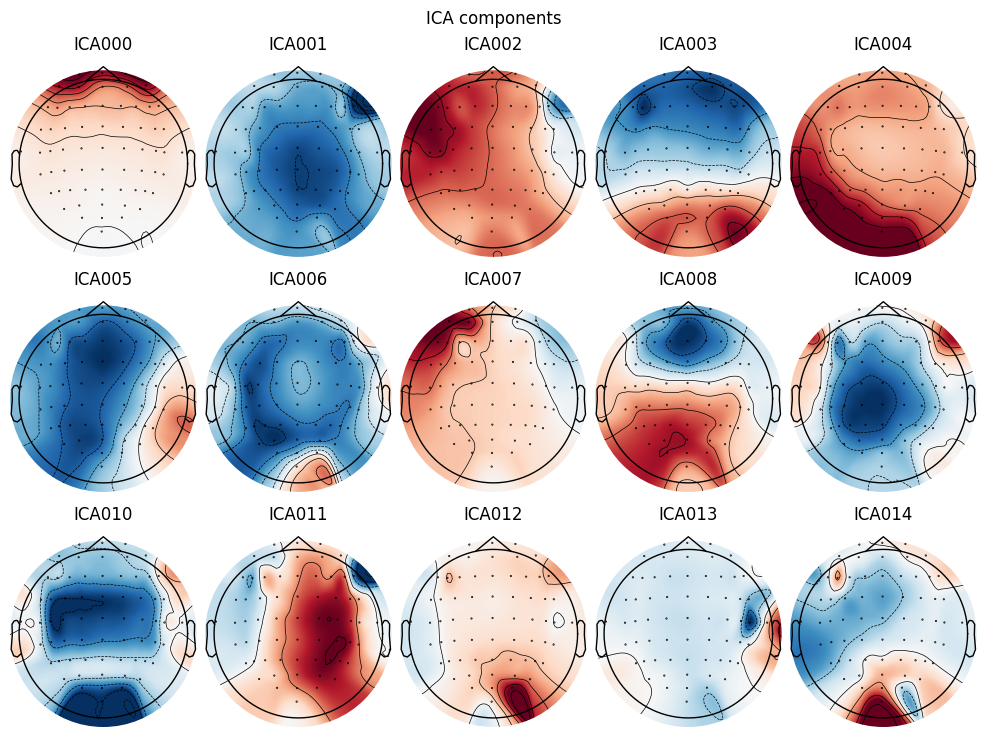

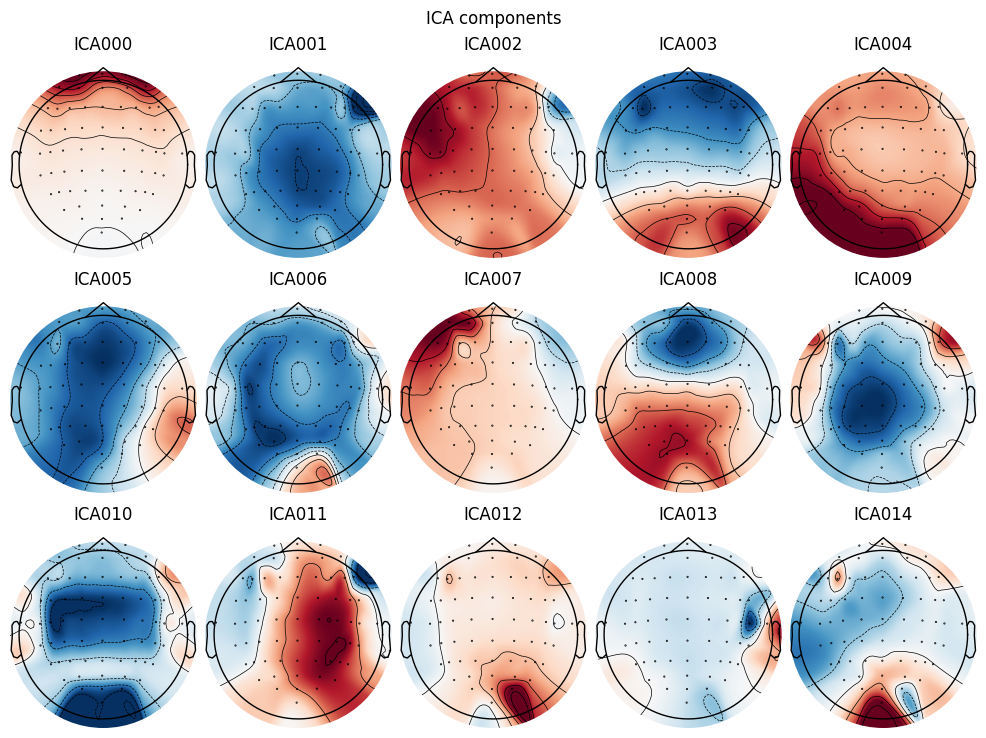

In [6]:
ica = mne.preprocessing.ICA(n_components=15, random_state=42, max_iter='auto') 
ica.fit(raw_filtered)
ica.plot_components()

Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components


/Users/olivialee/Library/Python/3.9/lib/python/site-packages/mne/preprocessing/ica.py:2370: RuntimeWarning: divide by zero encountered in matmul
  mixing = pca_components.T @ mixing
/Users/olivialee/Library/Python/3.9/lib/python/site-packages/mne/preprocessing/ica.py:2370: RuntimeWarning: overflow encountered in matmul
  mixing = pca_components.T @ mixing
/Users/olivialee/Library/Python/3.9/lib/python/site-packages/mne/preprocessing/ica.py:2370: RuntimeWarning: invalid value encountered in matmul
  mixing = pca_components.T @ mixing


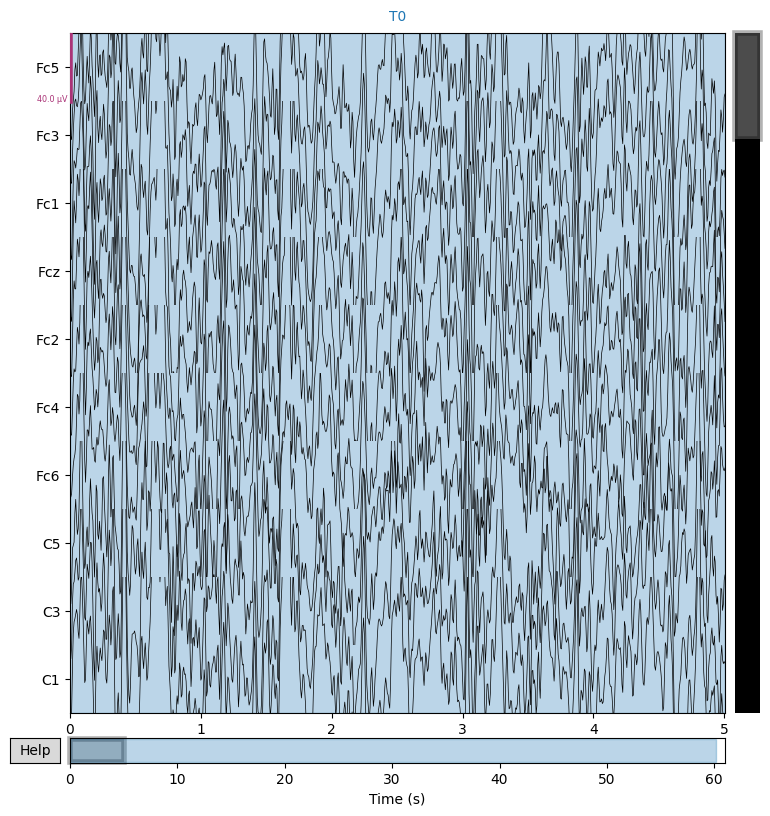

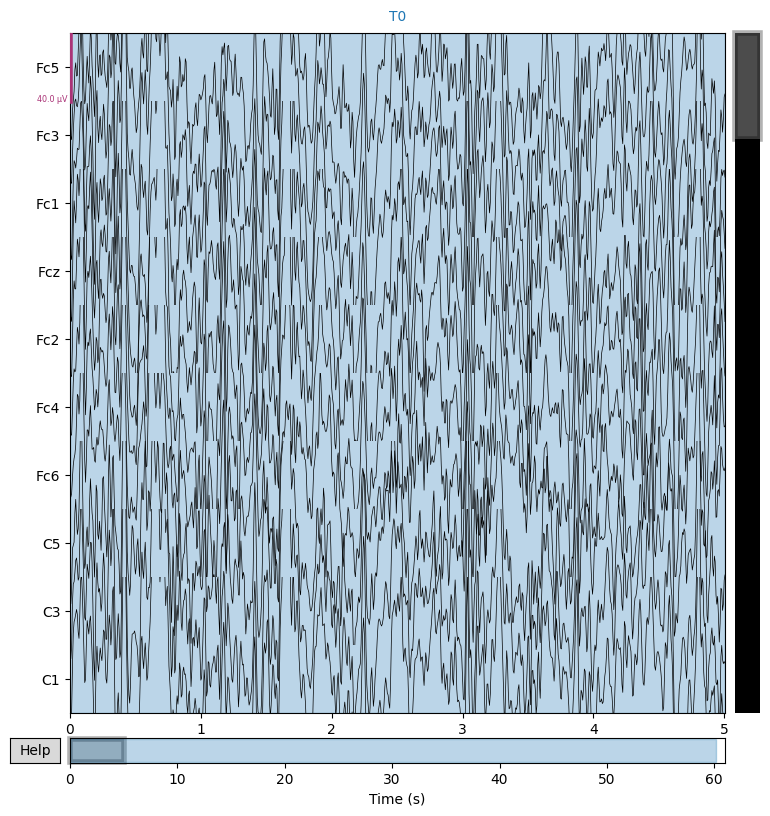

In [7]:
ica.exclude = [0]
raw_clean = raw_filtered.copy()
ica.apply(raw_clean)
raw_clean.plot(duration=5, n_channels=10)

In [8]:
raw_clean.save('../data/raw/preprocessed_raw.fif', overwrite=True)

Writing /Users/olivialee/Desktop/eeg-emotion-music/data/raw/notebooks/preprocessed_raw.fif
Closing /Users/olivialee/Desktop/eeg-emotion-music/data/raw/notebooks/preprocessed_raw.fif
[done]


In [9]:
bands = {
     "delta" : (1,4),
     "theta": (4,8),
     "alpha": (8,13),
     "beta": (13, 30),
     "gamma": (30,40),
 }

band_data = {}
for band_name, (low, high) in bands.items():
    band_data[band_name] = raw_clean.copy().filter(l_freq=low, h_freq=high, fir_design='firwin')
    print(f"{band_name} band done:{low}~{high}Hz")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Filter length: 529 samples (3.306 s)

delta band done:1~4Hz
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.0s finished


In [10]:
import os
os.makedirs('../data/raw/band_data', exist_ok=True)
for band_name, data in band_data.items():
    data.save(f'../data/raw/band_data/{band_name}_raw.fif', overwrite=True)
print("All bands are saved!")

Writing /Users/olivialee/Desktop/eeg-emotion-music/data/raw/notebooks/band_data/delta_raw.fif
Closing /Users/olivialee/Desktop/eeg-emotion-music/data/raw/notebooks/band_data/delta_raw.fif
[done]
Writing /Users/olivialee/Desktop/eeg-emotion-music/data/raw/notebooks/band_data/theta_raw.fif
Closing /Users/olivialee/Desktop/eeg-emotion-music/data/raw/notebooks/band_data/theta_raw.fif
[done]
Writing /Users/olivialee/Desktop/eeg-emotion-music/data/raw/notebooks/band_data/alpha_raw.fif
Closing /Users/olivialee/Desktop/eeg-emotion-music/data/raw/notebooks/band_data/alpha_raw.fif
[done]
Writing /Users/olivialee/Desktop/eeg-emotion-music/data/raw/notebooks/band_data/beta_raw.fif
Closing /Users/olivialee/Desktop/eeg-emotion-music/data/raw/notebooks/band_data/beta_raw.fif
[done]
Writing /Users/olivialee/Desktop/eeg-emotion-music/data/raw/notebooks/band_data/gamma_raw.fif
Closing /Users/olivialee/Desktop/eeg-emotion-music/data/raw/notebooks/band_data/gamma_raw.fif
[done]
All bands are saved!
